# Data analytics of banking customer churn 

*Now need to connect the sql workbench with this notebook for CRUD operation*

In [1]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mysql.connector

cnx = mysql.connector.connect(user='root', password='1552',
                              host='127.0.0.1',
                              port=3306,
                              database='banking_case')
cnx.close()

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
cnx = mysql.connector.connect(
    user='root',
    password='1552',
    host='127.0.0.1',
    port=3306,
    database='banking_case'
)

# Run query into DataFrame
query = "SELECT * FROM customer"
df = pd.read_sql(query, cnx)

# Close connection AFTER reading
cnx.close()

print(df.head())

  Client ID             Name  Age  Location ID Joined Bank   Banking Contact  \
0  IND81288    Raymond Mills   24        34324  06-05-2019    Anthony Torres   
1  IND65833    Julia Spencer   23        42205  10-12-2001  Jonathan Hawkins   
2  IND47499   Stephen Murray   27         7314  25-01-2010     Anthony Berry   
3  IND72498   Virginia Garza   40        34594  28-03-2019        Steve Diaz   
4  IND60181  Melissa Sanders   46        41269  20-07-2012        Shawn Long   

  Nationality            Occupation Fee Structure Loyalty Classification  ...  \
0    American  Safety Technician IV          High                   Jade  ...   
1     African   Software Consultant          High                   Jade  ...   
2    European    Help Desk Operator          High                   Gold  ...   
3    American          Geologist II           Mid                 Silver  ...   
4    American   Assistant Professor           Mid               Platinum  ...   

   Bank Deposits  Checking Accou

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\691333832.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


In [4]:
df.shape

(3000, 25)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   str    
 5   Banking Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee Structure             3000 non-null   str    
 9   Loyalty Classification    3000 non-null   str    
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loans         

In [6]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='str')

In [7]:
df.isnull().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [8]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


# No nulls and and not statistical wrong information found here

In [9]:
df.tail(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
2995,IND66827,Earl Hall,82,8760,09-10-2014,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1089957.03,532867.88,657849.62,12947.31,1238859.91,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,05-02-2009,Dennis Ruiz,European,Paralegal,Mid,Gold,...,136891.32,56581.74,93195.61,23205.69,277171.07,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,29-12-2009,Joshua Ryan,American,Statistician IV,Low,Jade,...,214860.89,158726.06,35539.15,30291.81,502947.22,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,13-02-2006,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,742630.22,404638.26,56411.33,6413.14,1538368.60,3,1,3,2,7
2999,IND40216,Amy Nguyen,79,38518,08-12-2005,Joe Hanson,American,Biostatistician III,High,Jade,...,65617.66,77769.08,32371.38,8992.36,329412.55,1,1,3,2,8


# Now seperting the categorical and numerical columns

In [10]:
categorical_features = list(df.select_dtypes(include=['object', 'string']).columns)
numerical_features  = list(df.select_dtypes(include=['float64','float32','int64','int32']).columns)

In [11]:
print("Categorical:\n" + "\n".join(categorical_features))
print("*" * 50)
print("Numerical:\n" + "\n".join(numerical_features))

Categorical:
Client ID
Name
Joined Bank
Banking Contact
Nationality
Occupation
Fee Structure
Loyalty Classification
**************************************************
Numerical:
Age
Location ID
Estimated Income
Superannuation Savings
Amount of Credit Cards
Credit Card Balance
Bank Loans
Bank Deposits
Checking Accounts
Saving Accounts
Foreign Currency Account
Business Lending
Properties Owned
Risk Weighting
BRId
GenderId
IAId


# Here I must convert some numerical attributes into categorical attributes

In [12]:
df = df.astype(
    {
    'BRId':'string',
    'GenderId':'string',
    'Amount of Credit Cards':'string',
    'Location ID':'string',
    'IAId': 'string'
    },
              )

In [13]:
categorical_features = list(df.select_dtypes(include=['object', 'string']).columns)
numerical_features  = list(df.select_dtypes(include=['float64','float32','int64','int32']).columns)
print("Categorical:\n" + "\n".join(categorical_features))
print("*" * 50)
print("Numerical:\n" + "\n".join(numerical_features))

Categorical:
Client ID
Name
Location ID
Joined Bank
Banking Contact
Nationality
Occupation
Fee Structure
Loyalty Classification
Amount of Credit Cards
BRId
GenderId
IAId
**************************************************
Numerical:
Age
Estimated Income
Superannuation Savings
Credit Card Balance
Bank Loans
Bank Deposits
Checking Accounts
Saving Accounts
Foreign Currency Account
Business Lending
Properties Owned
Risk Weighting


# Now need to create some bins from the numerical_features

In [14]:
bins = [0,100000,300000, float('inf')]
labels = ['low','medium','high']
df['Income Band'] = pd.cut(
    df['Estimated Income'],
    bins = bins,
    labels= labels,
    right = False,
    include_lowest = True
)

In [15]:
df['Income Band'].unique()

['low', 'medium', 'high']
Categories (3, str): ['low' < 'medium' < 'high']

In [16]:
df.drop(columns=['Estimated Income'], inplace=True)
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band'],
      dtype='str')

<Axes: xlabel='Income Band'>

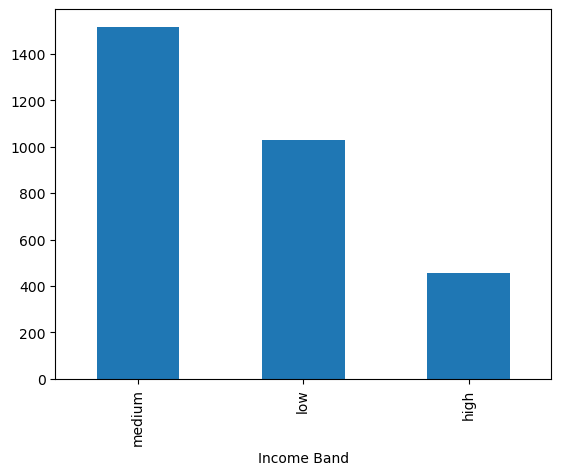

In [17]:
df['Income Band'].value_counts().plot(kind = 'bar')

<Axes: >

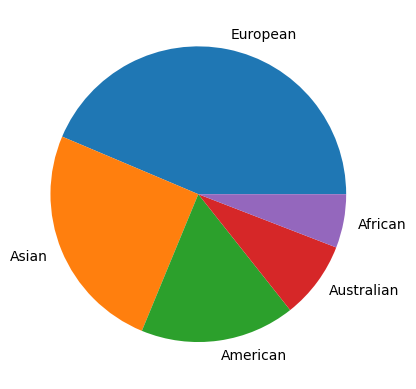

In [18]:
df['Nationality'].value_counts().plot(kind='pie')

In [21]:
print(type(df['Income Band']))

<class 'pandas.Series'>


In [26]:
# Separate categorical and numerical features
categorical_features = list(df.select_dtypes(include=['object', 'string',]).columns)
if 'Income Band' in df.columns:
    categorical_features.append('Income Band')
numerical_features  = list(df.select_dtypes(include=['float64','float32','int64','int32']).columns)

print("Categorical:\n" + "\n".join(categorical_features))
print("*" * 50)
print("Numerical:\n" + "\n".join(numerical_features))

Categorical:
Client ID
Name
Location ID
Joined Bank
Banking Contact
Nationality
Occupation
Fee Structure
Loyalty Classification
Amount of Credit Cards
BRId
GenderId
IAId
Income Band
**************************************************
Numerical:
Age
Superannuation Savings
Credit Card Balance
Bank Loans
Bank Deposits
Checking Accounts
Saving Accounts
Foreign Currency Account
Business Lending
Properties Owned
Risk Weighting


In [31]:
if df.shape[1] == len(categorical_features)+len(numerical_features):
    print("the columns are all ok")
else:
    print("Lost or exaggerated columns")

the columns are all ok


In [40]:
df['Occupation'].value_counts()

Occupation
Associate Professor             28
Structural Analysis Engineer    28
Recruiter                       25
Account Coordinator             24
Human Resources Manager         24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

In [36]:
# Get the counts
counts = df['Income Band'].value_counts()

# Extract categorical values (the labels)
categories = counts.index.tolist()

# Extract numerical values (the counts)
numbers = counts.values.tolist()

print("Categories:", categories)
print("Counts:", numbers)


Categories: ['medium', 'low', 'high']
Counts: [1517, 1027, 456]


# Now here comes the visualization part

**Here I am visualizing the categorical values**

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\1908306123.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(


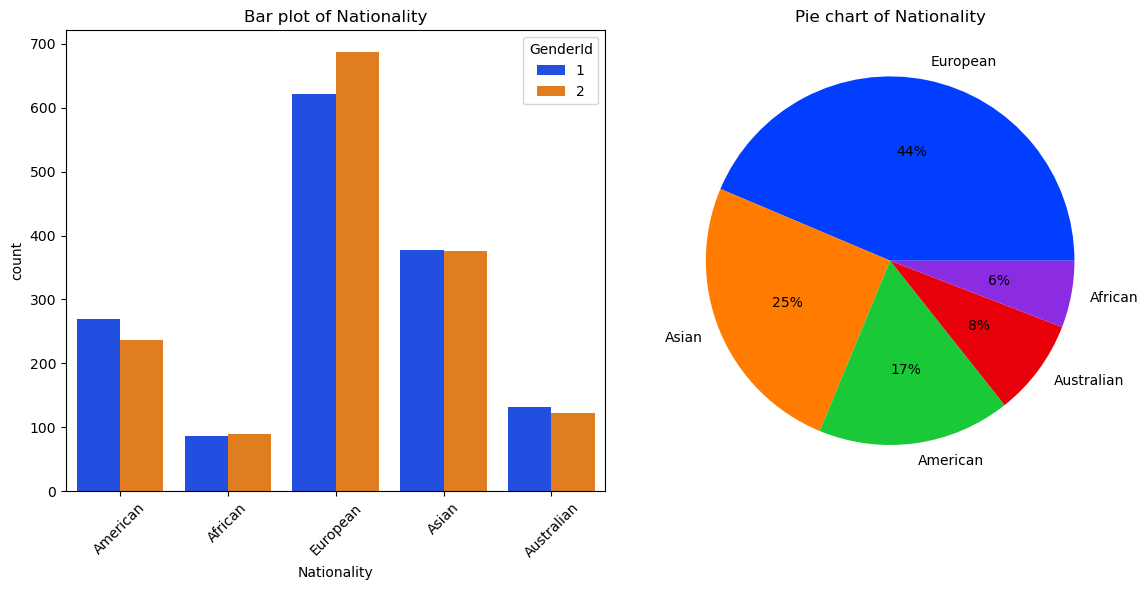

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\1908306123.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(


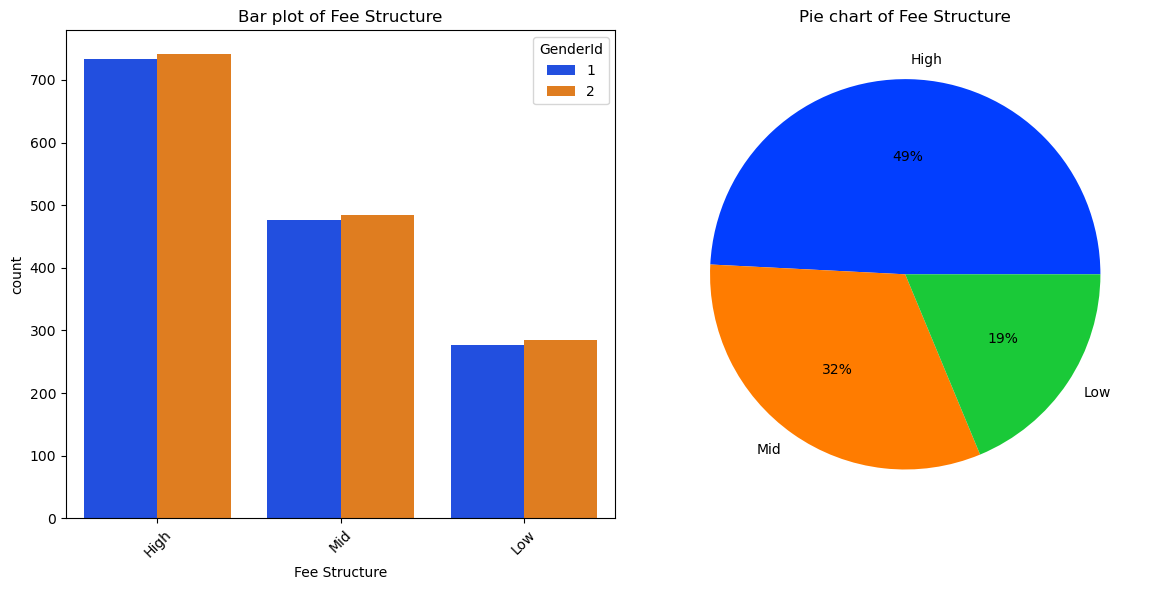

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\1908306123.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(


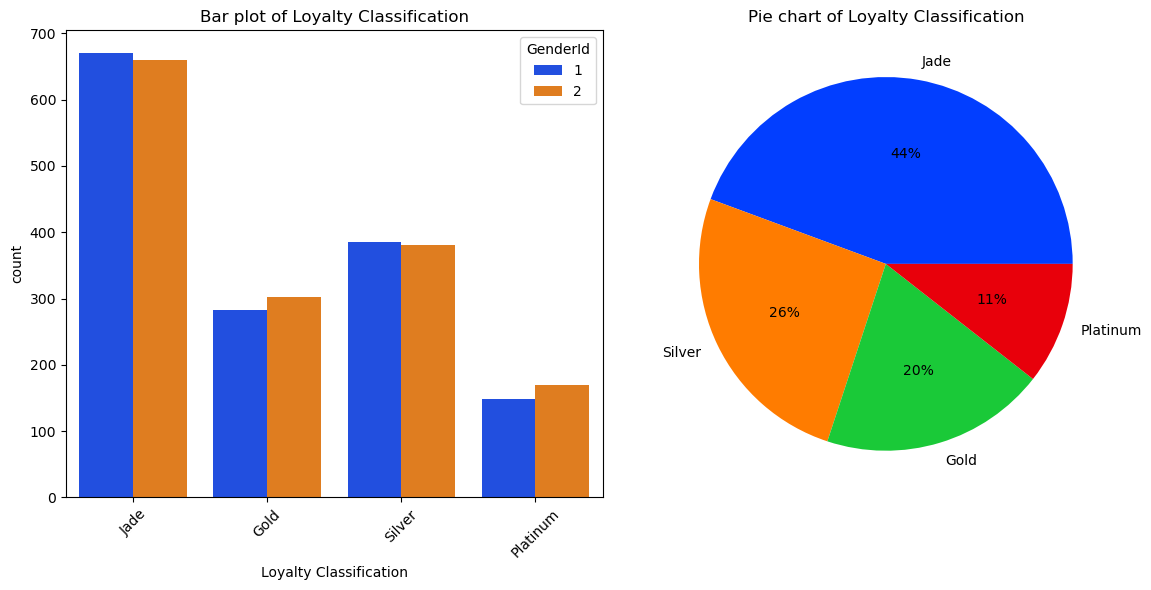

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\1908306123.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(


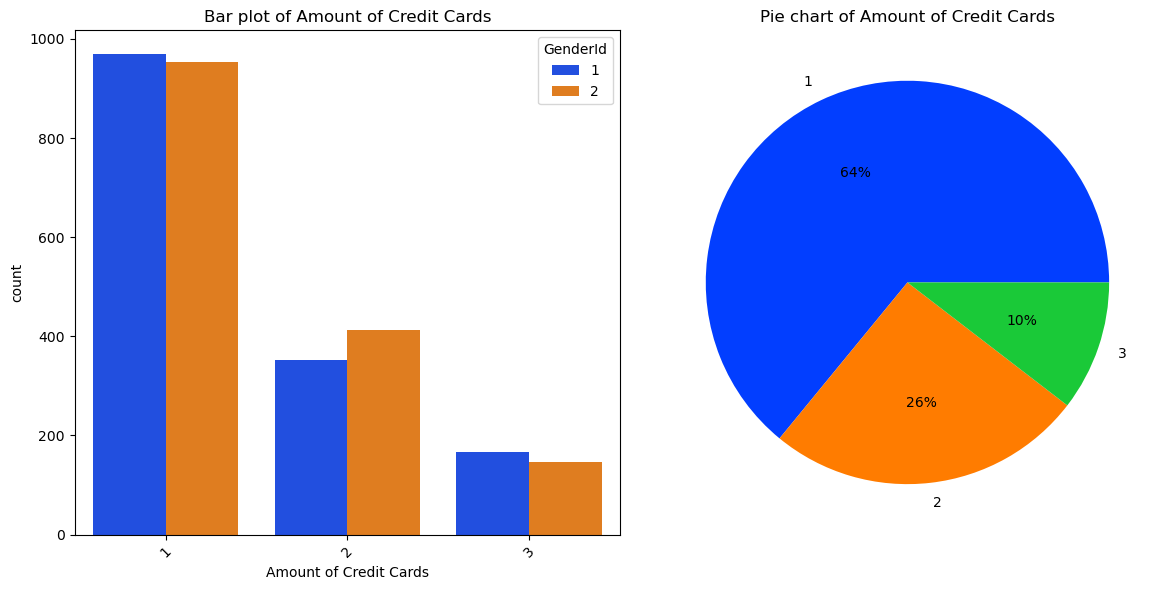

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\1908306123.py:15: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(


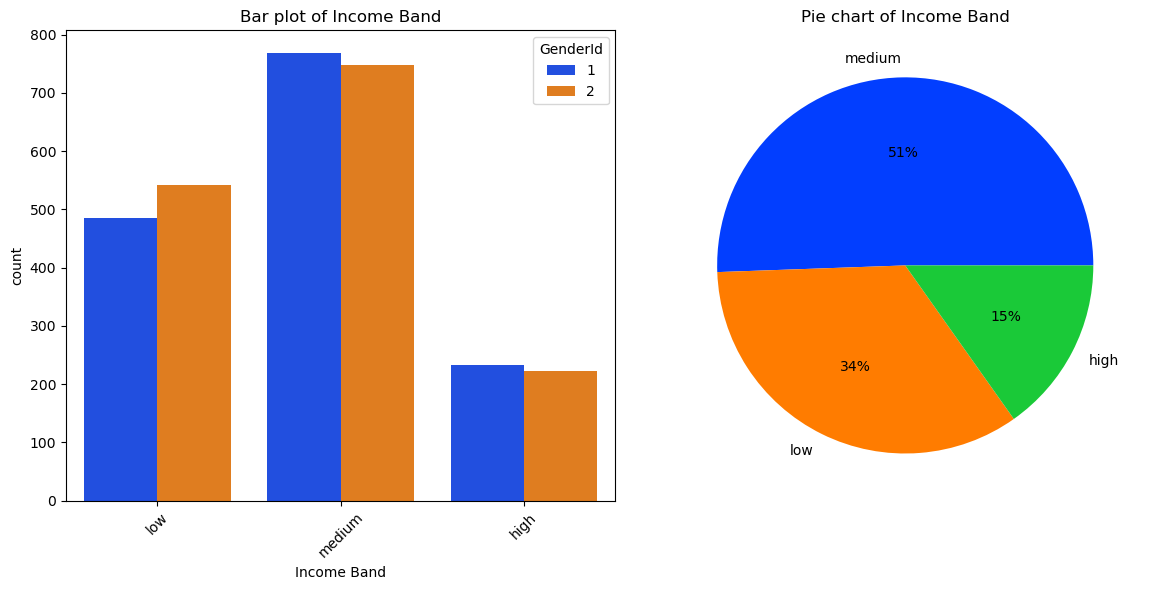

In [44]:
colors = sns.color_palette('bright')

for attributes in categorical_features:
    if attributes in ['Client ID','Name','Location ID','BRId','GenderId','IAId','Joined Bank','Banking Contact','Occupation']:
        continue
    
    counts = df[attributes].value_counts()
    values = counts.values.tolist()
    categories = counts.index.tolist()

    # Create 1 row, 2 columns of subplots (side by side)
    fig, axes = plt.subplots(1, 2, figsize=(12,6))

    # Bar plot with gender breakdown
    sns.countplot(
        data=df,
        x=attributes,
        hue='GenderId',
        ax=axes[0],
        palette=colors
    )
    axes[0].set_title(f"Bar plot of {attributes}")
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart of overall distribution
    axes[1].pie(
        values,
        labels=categories,
        colors=colors,
        autopct="%.0f%%"
    )
    axes[1].set_title(f"Pie chart of {attributes}")

    plt.tight_layout()
    plt.show()

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\3559414589.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(


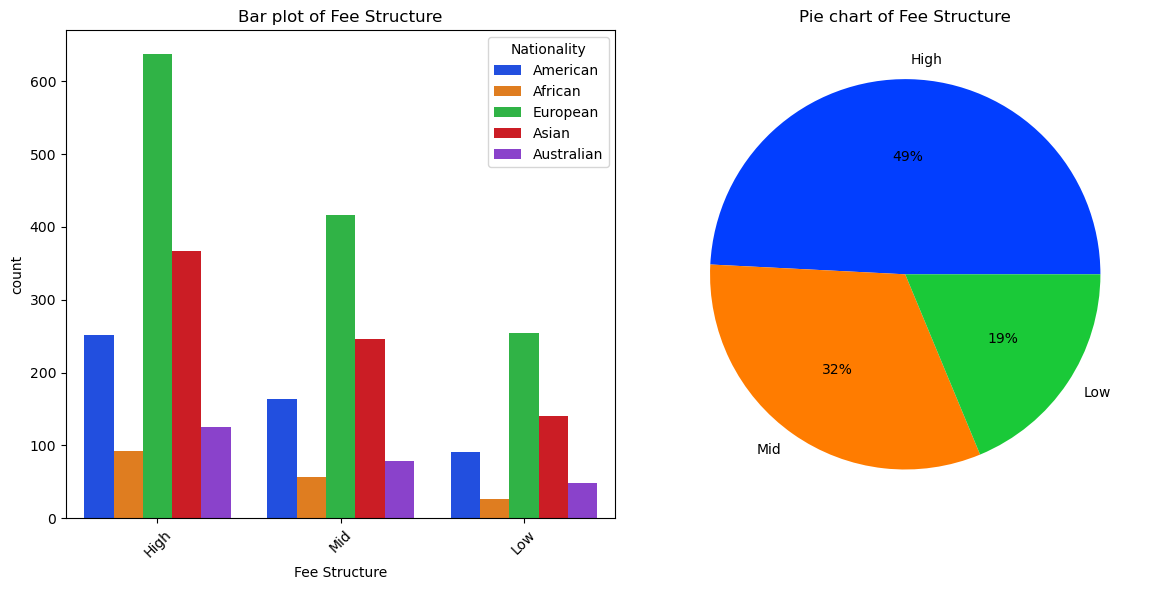

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\3559414589.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(


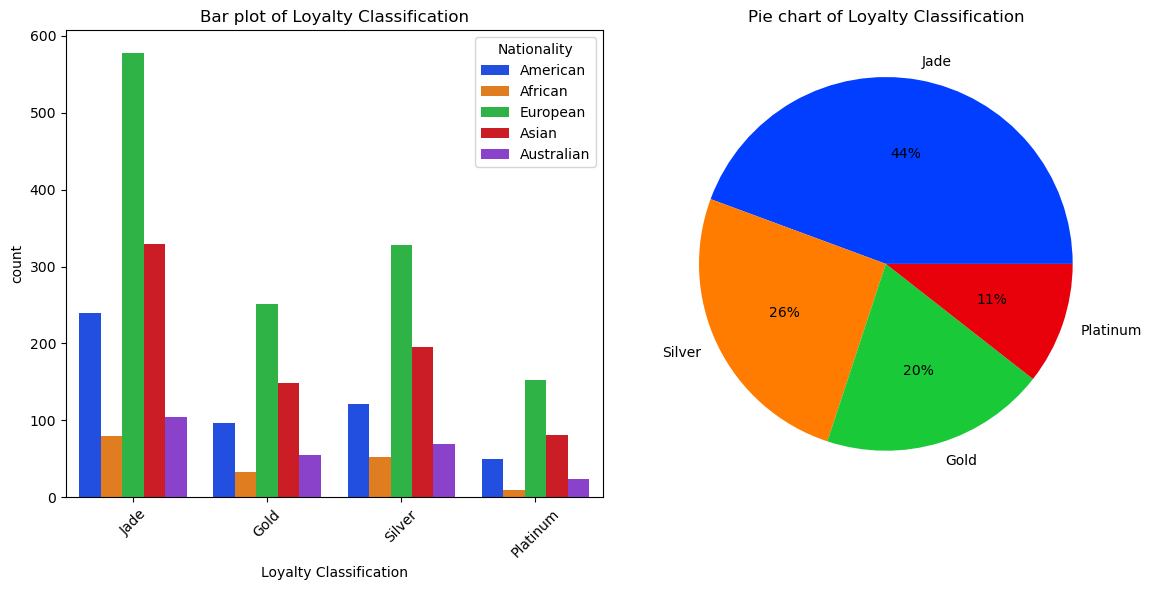

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\3559414589.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(


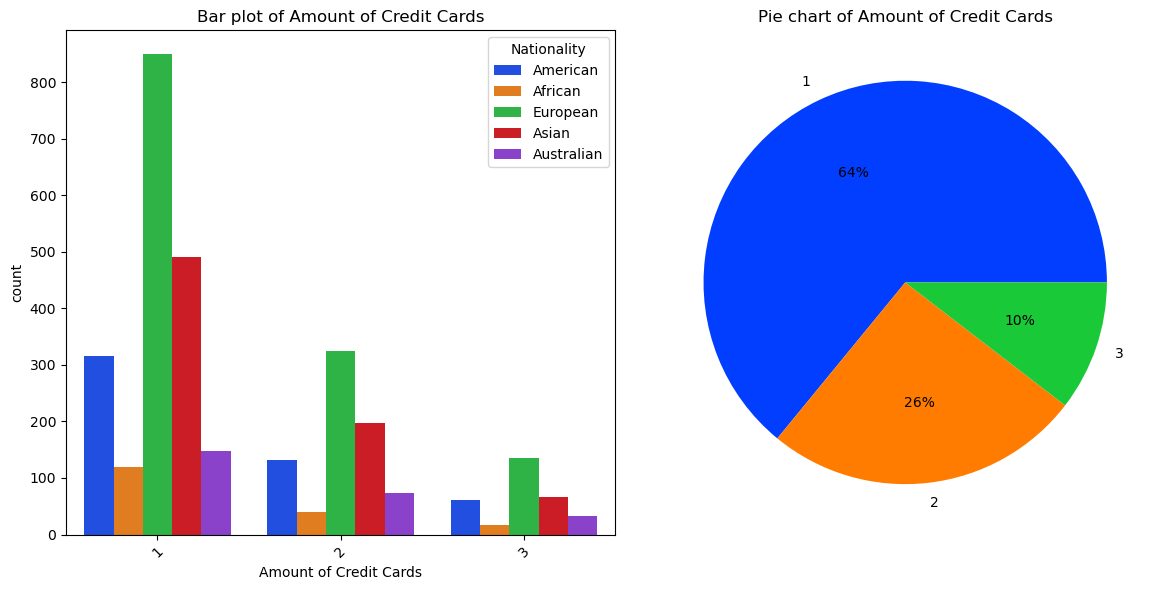

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\3559414589.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(


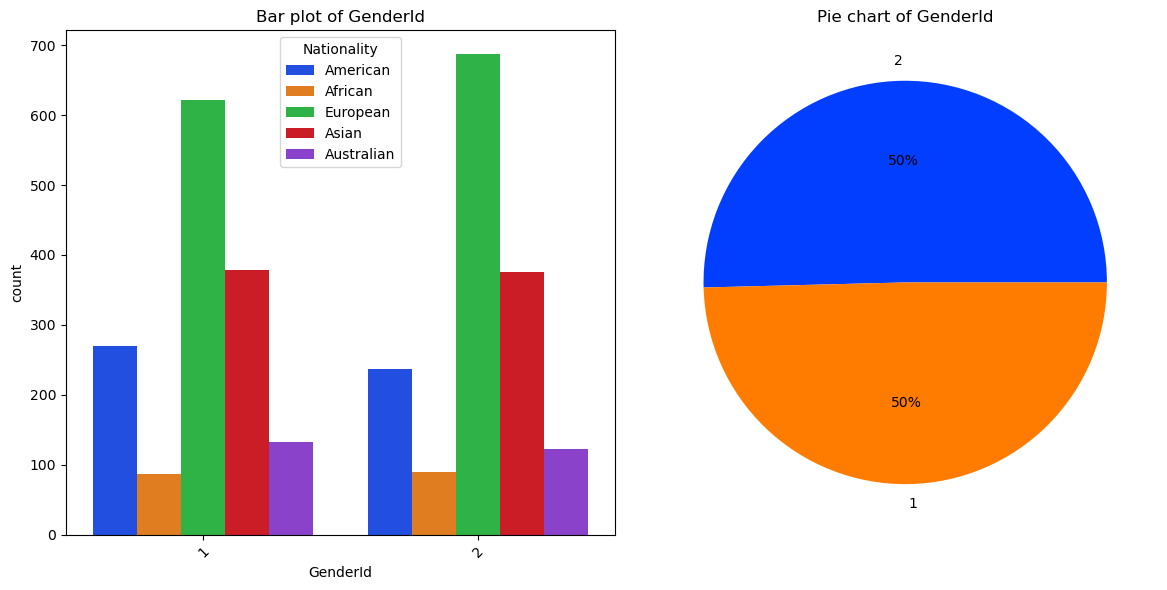

C:\Users\wwwal\AppData\Local\Temp\ipykernel_15580\3559414589.py:15: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(


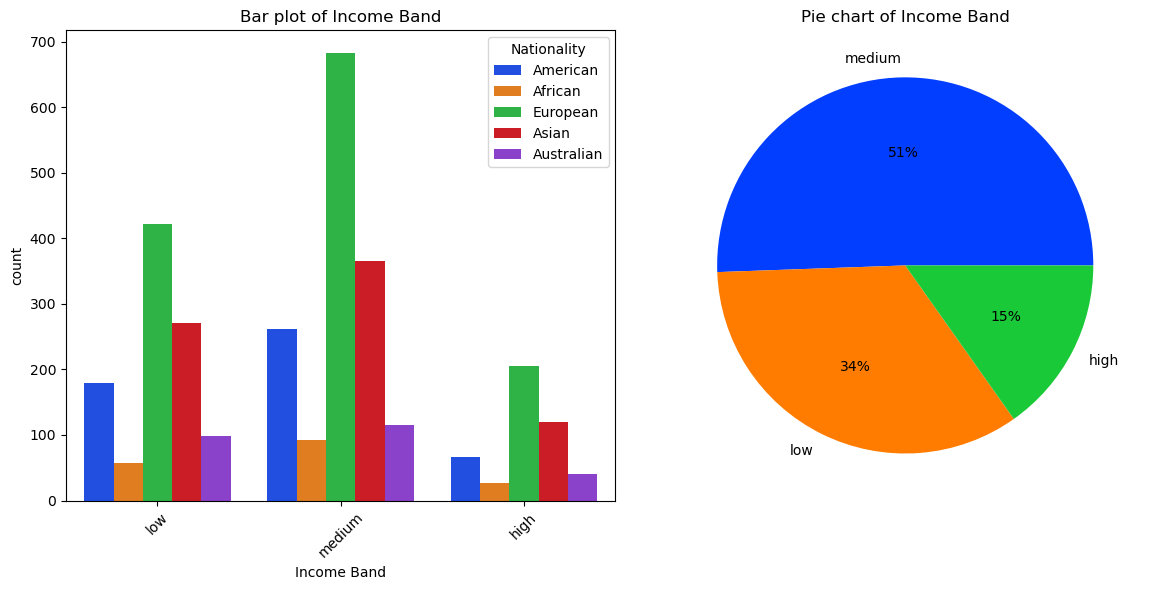

In [45]:
colors = sns.color_palette('bright')

for attributes in categorical_features:
    if attributes in ['Client ID','Name','Location ID','BRId','Nationality','IAId','Joined Bank','Banking Contact','Occupation']:
        continue
    
    counts = df[attributes].value_counts()
    values = counts.values.tolist()
    categories = counts.index.tolist()

    # Create 1 row, 2 columns of subplots (side by side)
    fig, axes = plt.subplots(1, 2, figsize=(12,6))

    # Bar plot with gender breakdown
    sns.countplot(
        data=df,
        x=attributes,
        hue='Nationality',
        ax=axes[0],
        palette=colors
    )
    axes[0].set_title(f"Bar plot of {attributes}")
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart of overall distribution
    axes[1].pie(
        values,
        labels=categories,
        colors=colors,
        autopct="%.0f%%"
    )
    axes[1].set_title(f"Pie chart of {attributes}")

    plt.tight_layout()
    plt.show()

#  Now lets move to the univariate analysis of numerical attributes

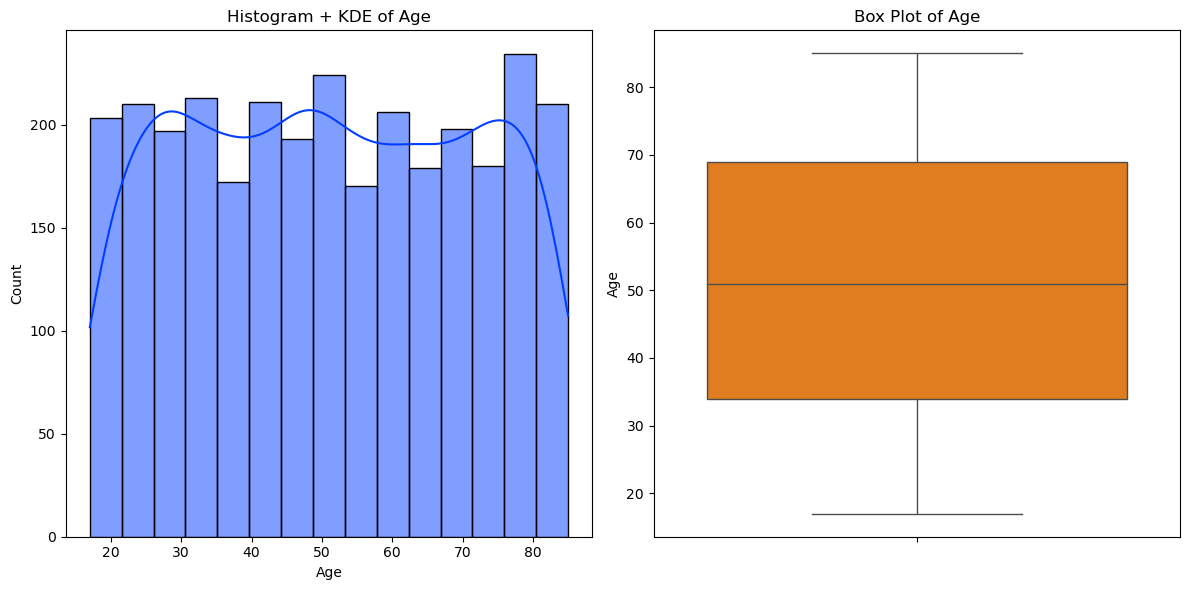

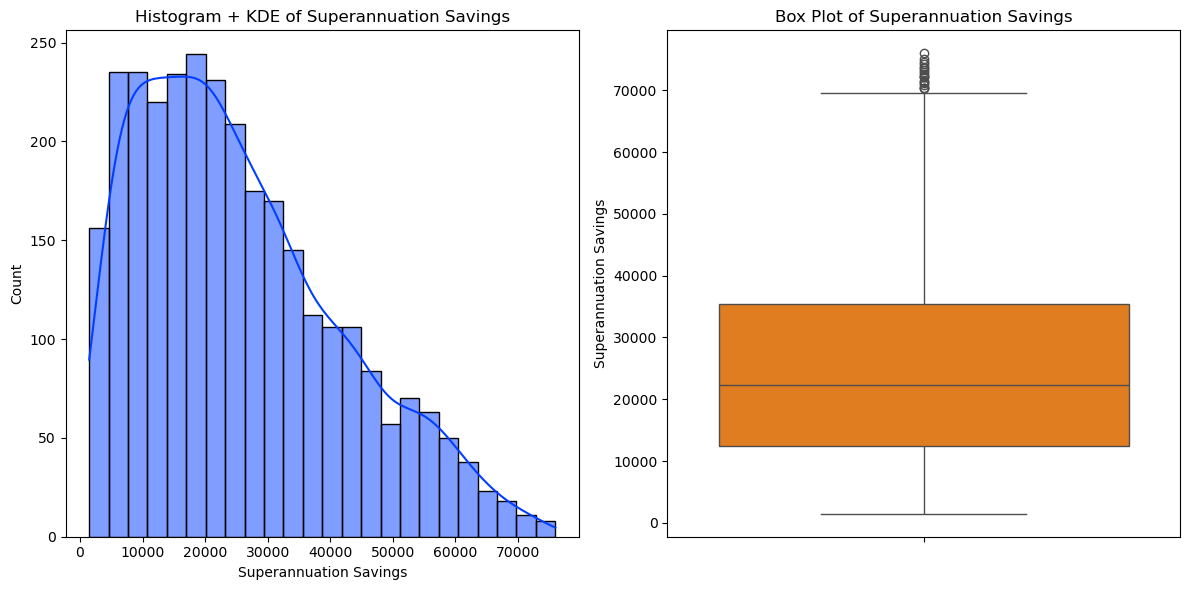

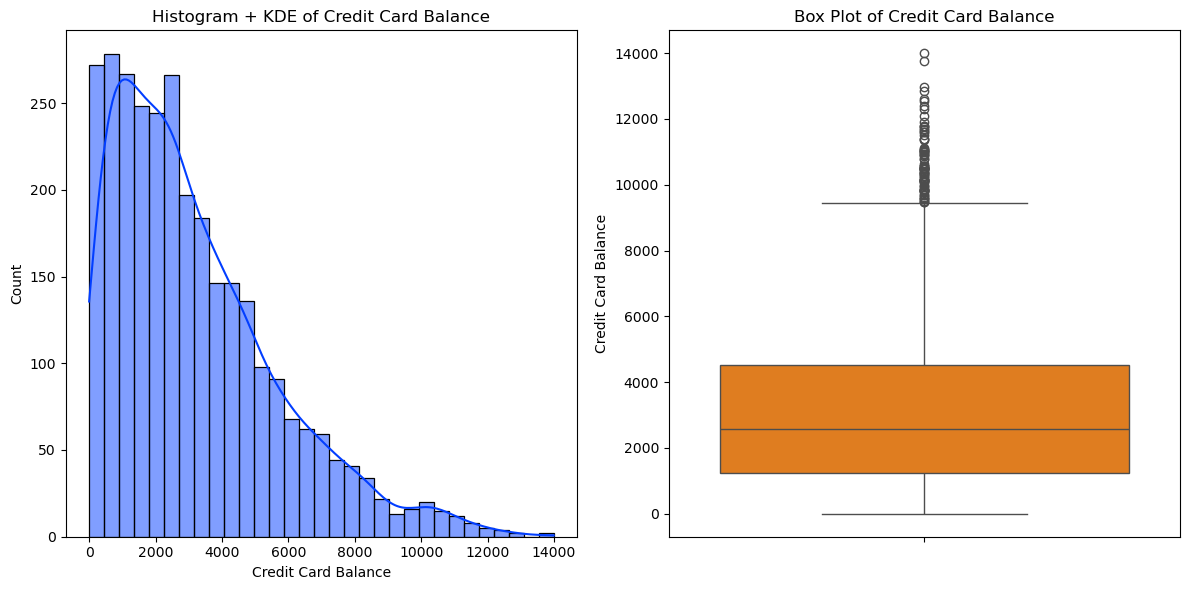

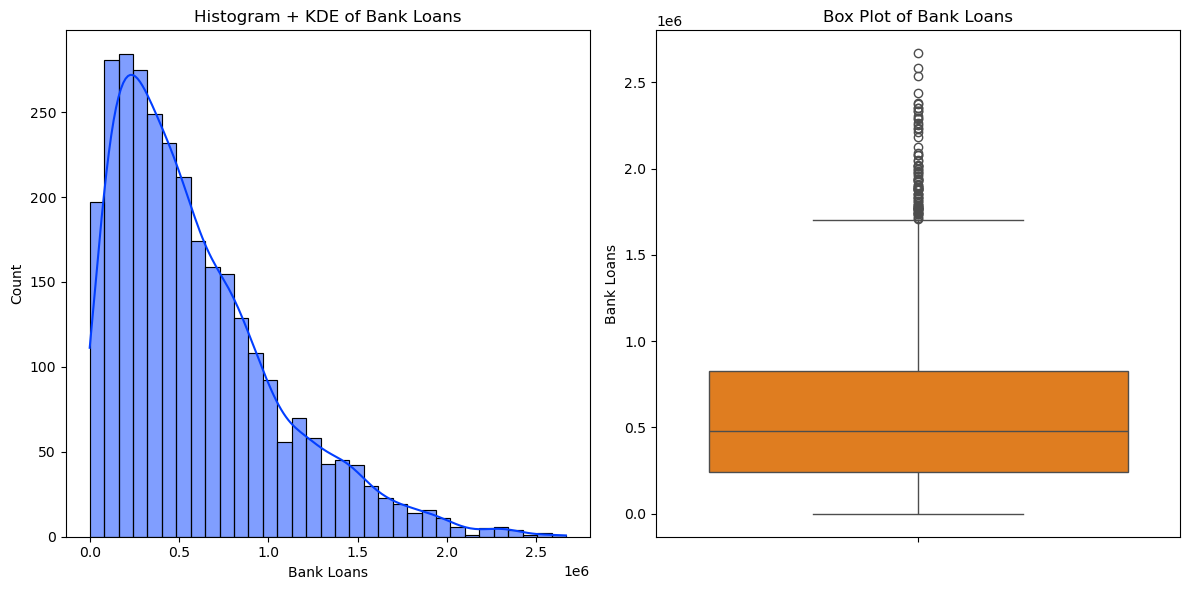

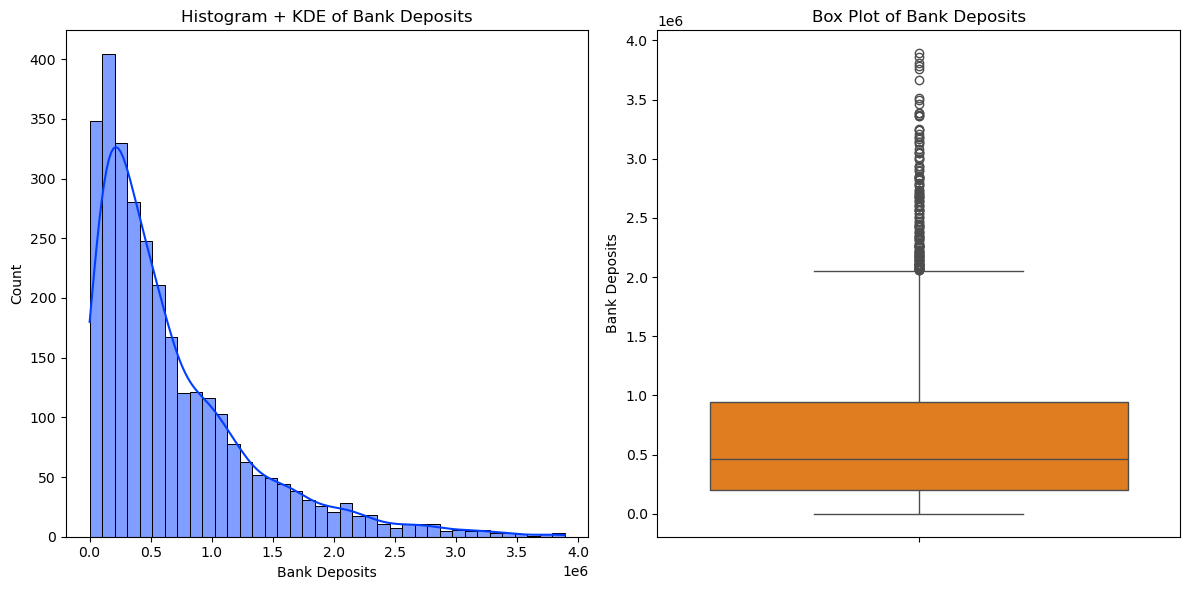

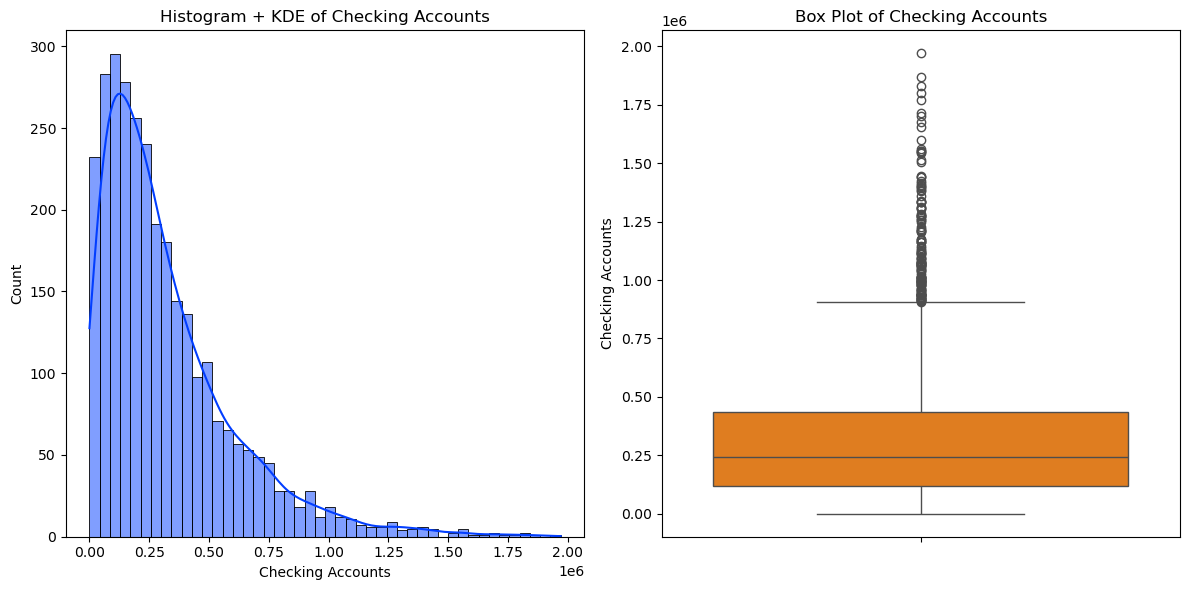

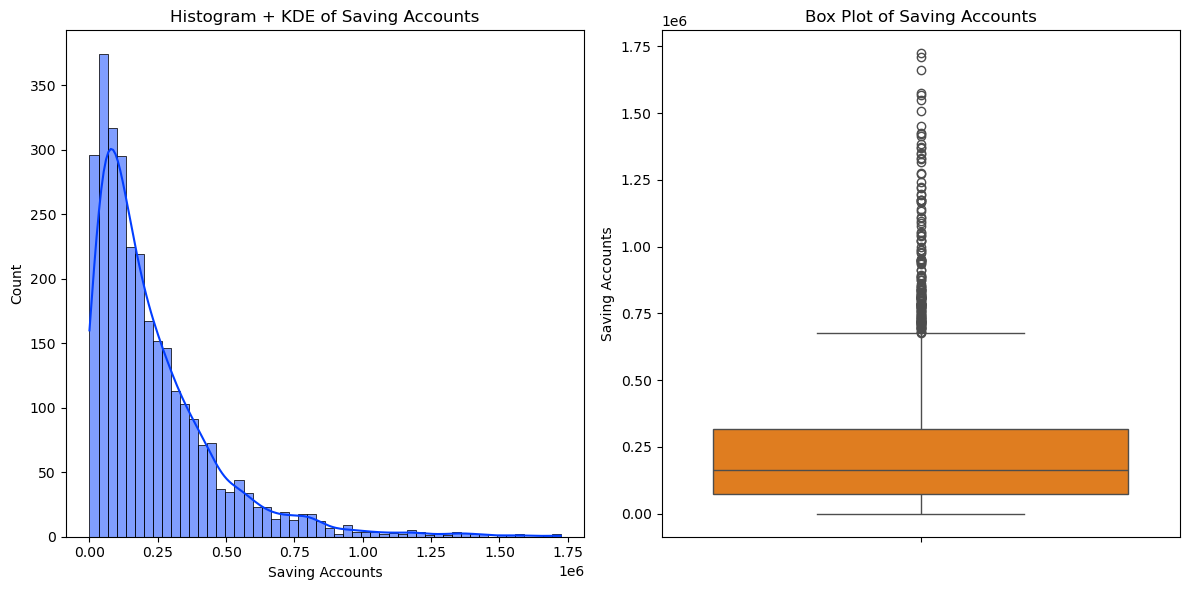

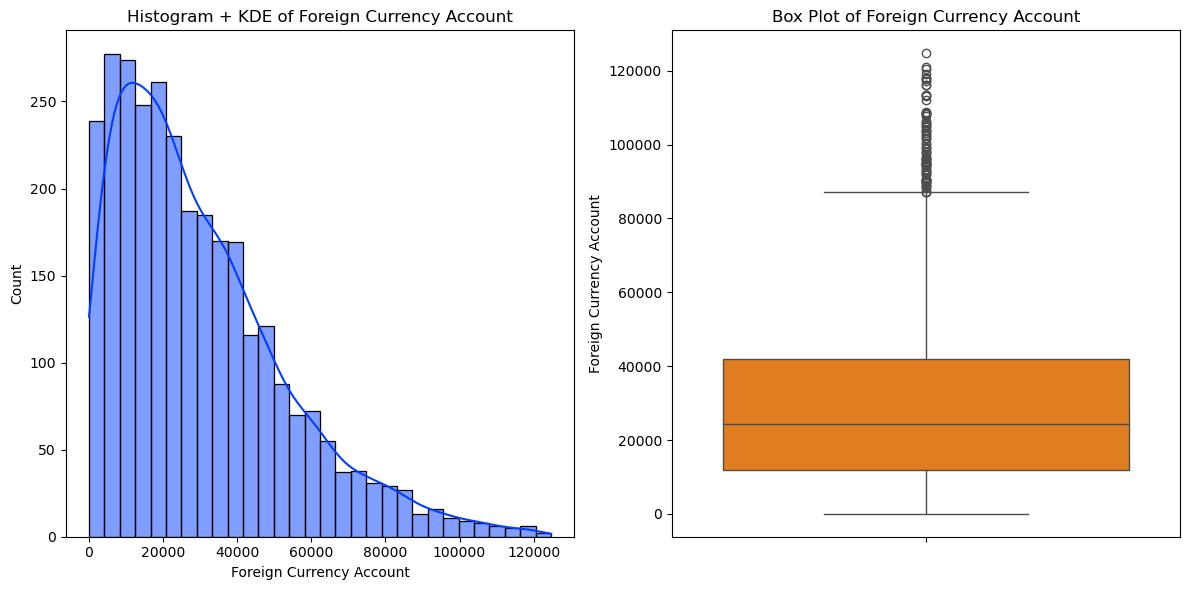

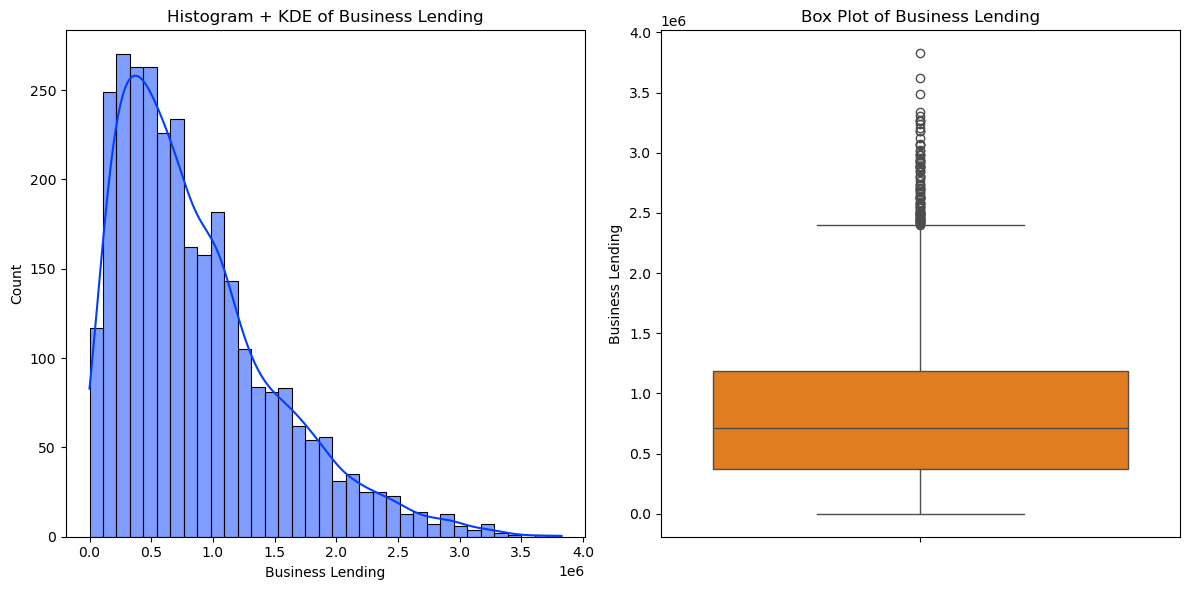

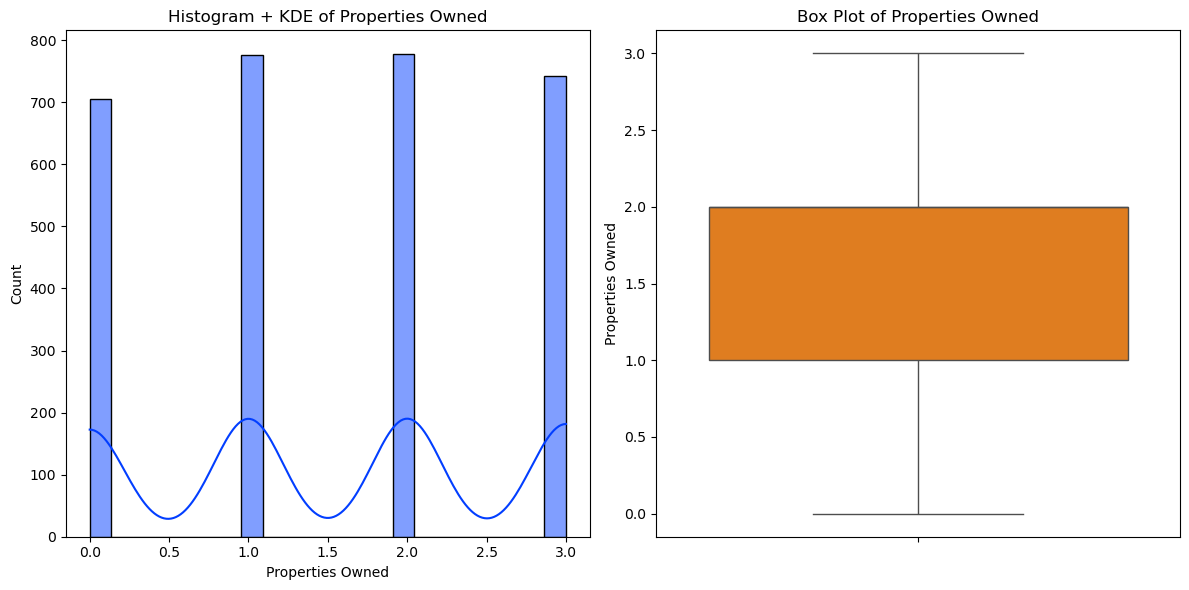

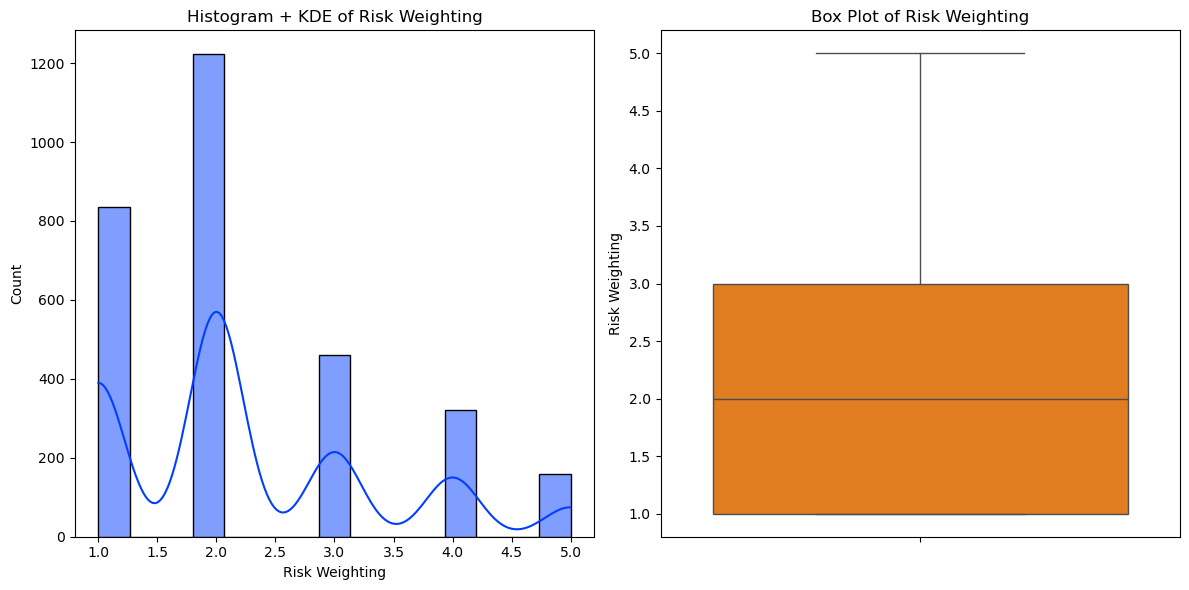

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('bright')

for num_attr in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(12,6))

    # Histogram + KDE (distribution)
    sns.histplot(
        data=df,
        x=num_attr,
        kde=True,          # adds KDE curve
        color=colors[0],
        ax=axes[0]
    )
    axes[0].set_title(f"Histogram + KDE of {num_attr}")

    # Box plot (spread + outliers)
    sns.boxplot(
        data=df,
        y=num_attr,
        color=colors[1],
        ax=axes[1]
    )
    axes[1].set_title(f"Box Plot of {num_attr}")

    plt.tight_layout()
    plt.show()

# Final verdict:
👥 Customer Demographics
Gender: Perfectly balanced — half male, half female.

Nationality: Europeans make up the largest group, followed by Asians. Americans, Australians, and Africans are smaller segments.

💰 Financial Profile
Income: Most customers are in the medium income band, fewer in low, and only a small share in high.

Fees: Nearly half of customers fall into the high fee structure, about a third in mid, and the rest in low.

Credit Cards: The majority hold just one card, fewer have two, and very few have three.

🎖️ Loyalty & Engagement
Loyalty Programs: Most customers are in the Jade tier (entry/mid‑level). Silver and Gold are smaller groups, and Platinum (top tier) is rare.

This shows strong participation but limited movement into the highest loyalty tier.

📊 Financial Accounts & Assets
Balances (savings, deposits, loans, credit cards): Most customers keep modest amounts, but a small number hold very large balances — these are the outliers that drive up averages.

Properties Owned: Most own 1–2 properties, very few own 3+.

Risk Weighting: Most customers sit around a moderate risk level (2 out of 5).

🔑 Key Takeaways for a Manager
Core customer profile: Medium income, high fee, Jade loyalty, and one credit card. This is your “bread and butter” group.

High‑value outliers: A small number of customers hold very large deposits, loans, or savings. They’re important but rare.

Balanced gender split: No major gender bias — strategies can target both equally.

European/Asian dominance: These groups drive most of the numbers. Smaller nationalities are present but less influential.

Growth opportunity: Moving customers from Jade/Silver into Gold/Platinum loyalty tiers could increase engagement and revenue.

👉 In simple terms: your customer base is stable, balanced by gender, dominated by Europeans and Asians, mostly medium‑income, and loyal at mid‑tier levels. The majority are “everyday” customers with modest accounts, while a small elite group holds very high balances.

Would you like me to turn this into a one‑page executive dashboard summary (with bullet points and visuals) that a manager could drop straight into a presentation?